# Visualize System Embeddings

The purpose of this notebook is to visualize the embeddings of systems under different mutation profiles and analyze how these embeddings can be used to groups cells. We can then use the results from cluster_embeddings to understand the overrepresented genomic profiles that make up these clusters

## Analyze Dict from `cluster_embeddings.py`

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from decimal import Decimal
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
with open("results_integrin.pkl", "rb") as handle:
    results = pickle.load(handle)
    
with open("clustered_embeddings_integrin.pkl", "rb") as handle:
    clustered_embeddings = pickle.load(handle)

with open("mappings/system_to_genes.pkl", "rb") as handle:
    system_genes = pickle.load(handle)

with open("mappings/nest_to_old_name.pkl", "rb") as handle:
    nest_to_name = pickle.load(handle)

with open("mappings/index_to_nest.pkl", "rb") as handle:
    index_to_nest = pickle.load(handle)

with open("important_systems_integrin.pkl", "rb") as handle:
    important_systems = pickle.load(handle)

with open("integrin_importance_pvalues.pkl", "rb") as handle:
    importance_pvalues = pickle.load(handle)

## Visualize System Embeddings Clusters Colored by Drug Response

### Code Version 1

In [3]:
def visualize_embedding_response_1(results, cluster_info, system):

    name_to_nest = dict((v,k) for k,v in nest_to_name.items())
    nest_to_index = dict((v,k) for k,v in index_to_nest.items())
    system_index = nest_to_index[name_to_nest[system]]
    system_clusters = cluster_info[system]["Clusters"]

    system_embeddings = []
    for drug in results.keys():
        cells = results[drug]["celllines"]
        embeddings = results[drug]["system_embeddings"][:, system_index, :]
        embeddings = pd.DataFrame(embeddings, index = cells)
        if isinstance(system_embeddings, pd.DataFrame):
            merged_embeddings = pd.concat([system_embeddings, embeddings], axis=0, join='outer')
            merged_embeddings = merged_embeddings[~merged_embeddings.index.duplicated(keep='first')]                
            system_embeddings = merged_embeddings
        else:
            system_embeddings = embeddings

    cluster_name_indices = {}
    for cluster in system_clusters:
        cluster_cells = system_clusters[cluster]["Cells"]
        cluster_response = system_clusters[cluster]["Response"]
        
        best_cluster_fdr = 1.0
        for drug in cluster_response.keys():
            if cluster_response[drug]["Res FDR"] < cluster_response[drug]["Sen FDR"]:
                better_response = "Res FDR"
            else:
                better_response = "Sen FDR"
            if cluster_response[drug]["Acc FDR"] < 0.05:
                if cluster_response[drug][better_response] < best_cluster_fdr:
                    best_cluster_drug = drug
                    best_cluster_response = better_response
                    best_cluster_fdr = cluster_response[drug][better_response]

        if best_cluster_fdr < 0.05:
            if best_cluster_fdr < 0.001:
                fdr = str("{:.2e}".format(Decimal(best_cluster_fdr)))
                fdr = "(q = "+fdr+")"
            else:
                fdr = str(round(best_cluster_fdr, 4))
                fdr = "(q = "+fdr+")"
            cluster_response = best_cluster_response.split()[0]
            cluster_name = best_cluster_drug+" "+cluster_response+" "+fdr
            cluster_name_indices[cluster_name] = [system_embeddings.index.get_loc(cell) for cell in cluster_cells]
        else:
            cluster_name = "Insignificant cluster "+str(cluster)
            cluster_name_indices[cluster_name] = [system_embeddings.index.get_loc(cell) for cell in cluster_cells]

    matrix = np.asarray(system_embeddings)
    tsne_model = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_result = tsne_model.fit_transform(matrix)

    num_labels = len(cluster_name_indices.keys())
    cmap = cm.get_cmap("tab20", num_labels)
    colors = [cmap(i) for i in range(num_labels)]

    plt.figure(figsize=(10, 8))

    for i, (label, indices) in enumerate(cluster_name_indices.items()):
        if "Insignificant" in label:
            marker = "x"
        elif "Res" in label:
            marker = "^"
        elif "Sen" in label:
            marker = "o"
        plt.scatter(tsne_result[indices, 0], tsne_result[indices, 1], label=label, color=colors[i % len(colors)], marker=marker, alpha=0.7)

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title("Significant Response within Clusters of "+system+" Embeddings", fontsize=12)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize="small", title="Top Response in Cluster")
    plt.grid(True)
    plt.show()

### Code Version 2

In [4]:
from decimal import Decimal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE

def visualize_embedding_response_2(results, cluster_info, system):
    # map system name to index
    name_to_nest   = {v:k for k,v in nest_to_name.items()}
    nest_to_index  = {v:k for k,v in index_to_nest.items()}
    system_index   = nest_to_index[name_to_nest[system]]
    system_clusters = cluster_info[system]["Clusters"]

    # build the full embeddings matrix for this system across all drugs
    system_embeddings = None
    for drug, res in results.items():
        cells      = res["celllines"]
        embeddings = pd.DataFrame(res["system_embeddings"][:, system_index, :],
                                  index=cells)
        if isinstance(system_embeddings, pd.DataFrame):
            merged = pd.concat([system_embeddings, embeddings], axis=0, join='outer')
            merged = merged.loc[~merged.index.duplicated(keep='first')]
            system_embeddings = merged
        else:
            system_embeddings = embeddings

    # now compute for each cluster: how many Res and Sen hits, and group them by label
    cluster_label_indices = {}
    total_drugs = None
    for cluster_id, cinfo in system_clusters.items():
        cell_list       = cinfo["Cells"]
        resp            = cinfo["Response"]
        if total_drugs is None:
            total_drugs = len(resp)
        # count significant Resist and Sensitive
        res_count = sum(1 for d in resp
                        if resp[d].get("Res FDR", 1.0) < 0.05)
        sen_count = sum(1 for d in resp
                        if resp[d].get("Sen FDR", 1.0) < 0.05)

        # build the label
        if res_count == 0 and sen_count == 0:
            label = "Insignificant Response"
        else:
            parts = []
            if res_count > 0:
                parts.append(f"Res {res_count}/{total_drugs} drugs")
            if sen_count > 0:
                parts.append(f"Sen {sen_count}/{total_drugs} drugs")
            label = ", ".join(parts)

        # translate cell IDs to embedding‐matrix indices
        indices = [system_embeddings.index.get_loc(c)
                   for c in cell_list
                   if c in system_embeddings.index]

        # aggregate all clusters with the same label
        cluster_label_indices.setdefault(label, []).extend(indices)

    # run t-SNE on the full matrix
    matrix    = system_embeddings.values
    tsne_model = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_result = tsne_model.fit_transform(matrix)

    # pick one color per distinct label
    labels     = list(cluster_label_indices.keys())
    cmap       = cm.get_cmap("tab20", len(labels))
    colors     = [cmap(i) for i in range(len(labels))]

    plt.figure(figsize=(10, 8))
    for i, label in enumerate(labels):
        inds = cluster_label_indices[label]
        # same markers logic as before
        if "Insignificant" in label:
            marker = "x"
        elif "Res" in label:
            marker = "^"
        elif "Sen" in label:
            marker = "o"
        else:
            marker = "o"
        plt.scatter(tsne_result[inds, 0],
                    tsne_result[inds, 1],
                    label=label,
                    color=colors[i],
                    marker=marker,
                    alpha=0.7)

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(f"Significant Response within Clusters of {system} Embeddings", fontsize=12)
    plt.legend(bbox_to_anchor=(1, 1),
               loc='upper left',
               fontsize="small",
               title="Significant Responses")
    plt.grid(True)
    plt.show()

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


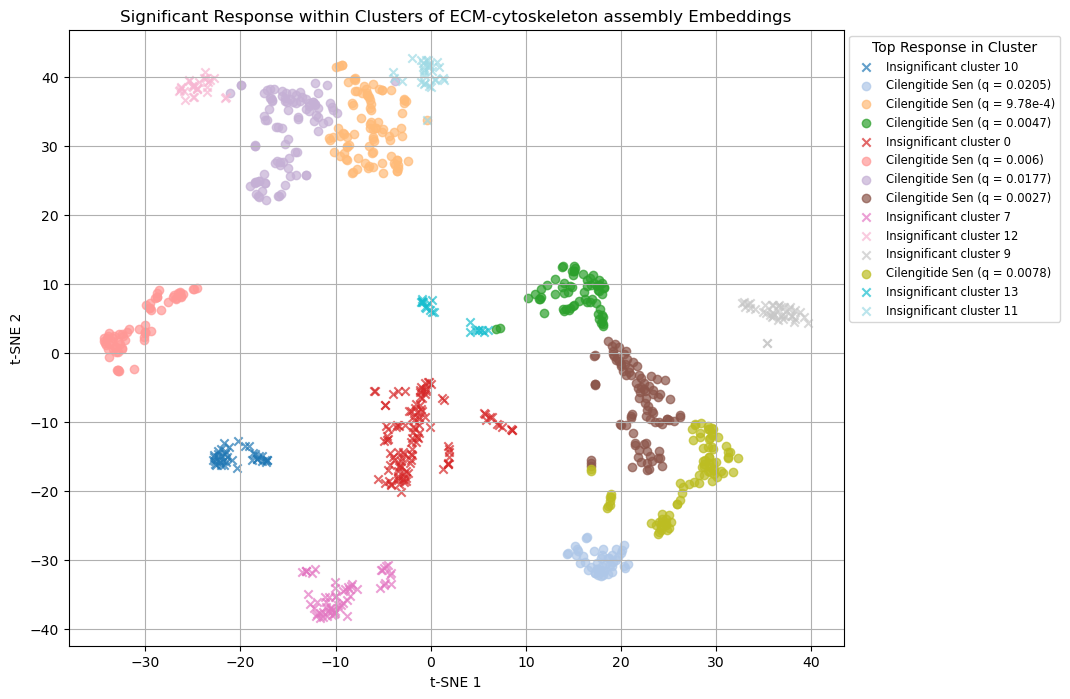

In [5]:
visualize_embedding_response_1(results, clustered_embeddings, "ECM-cytoskeleton assembly")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


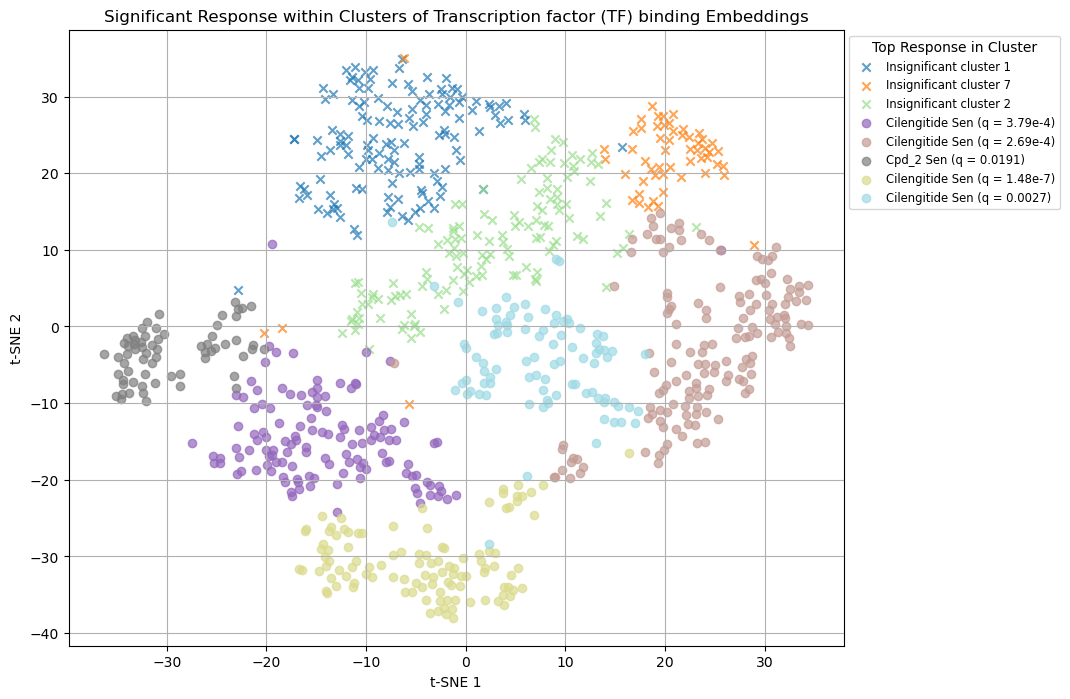

In [6]:
visualize_embedding_response_1(results, clustered_embeddings, "Transcription factor (TF) binding")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


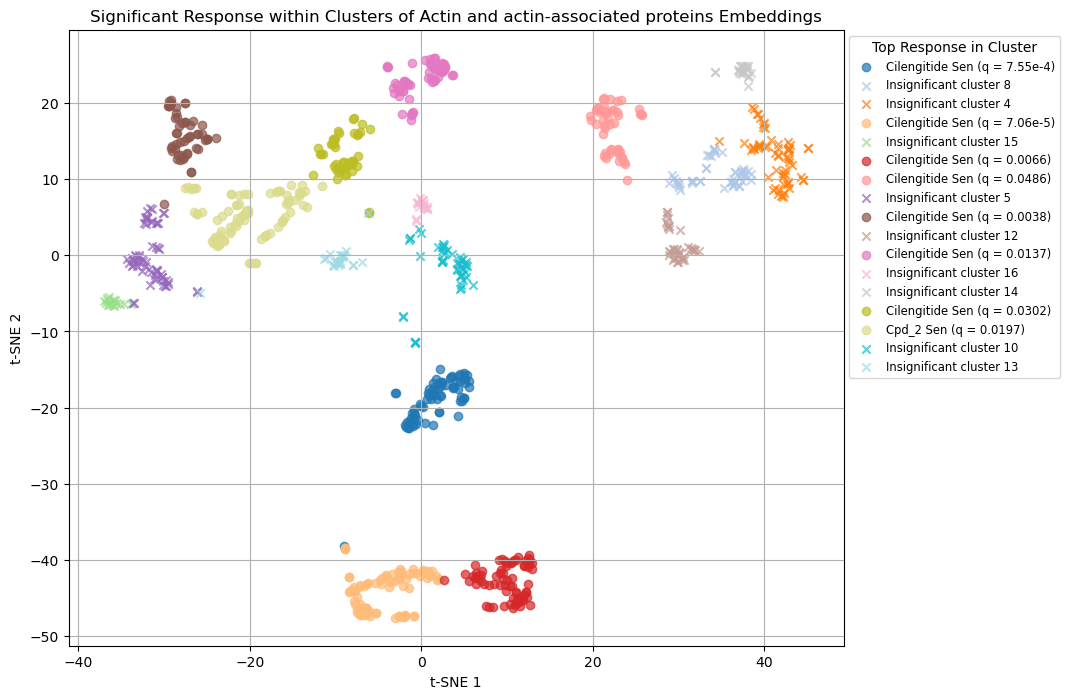

In [7]:
visualize_embedding_response_1(results, clustered_embeddings, "Actin and actin-associated proteins")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


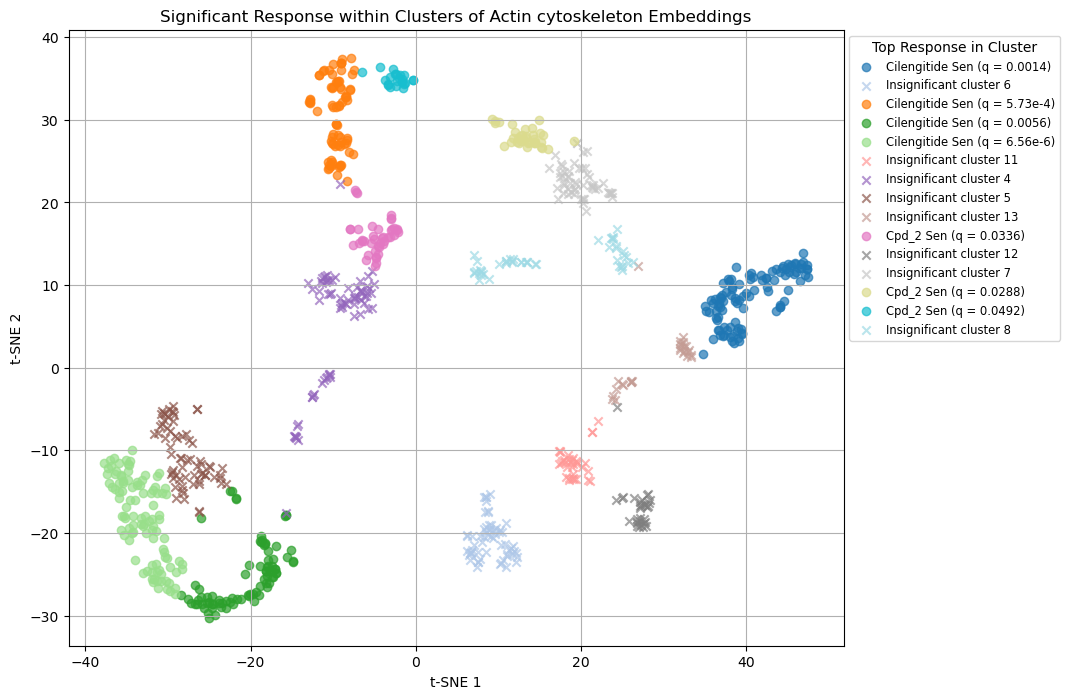

In [8]:
visualize_embedding_response_1(results, clustered_embeddings, "Actin cytoskeleton")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


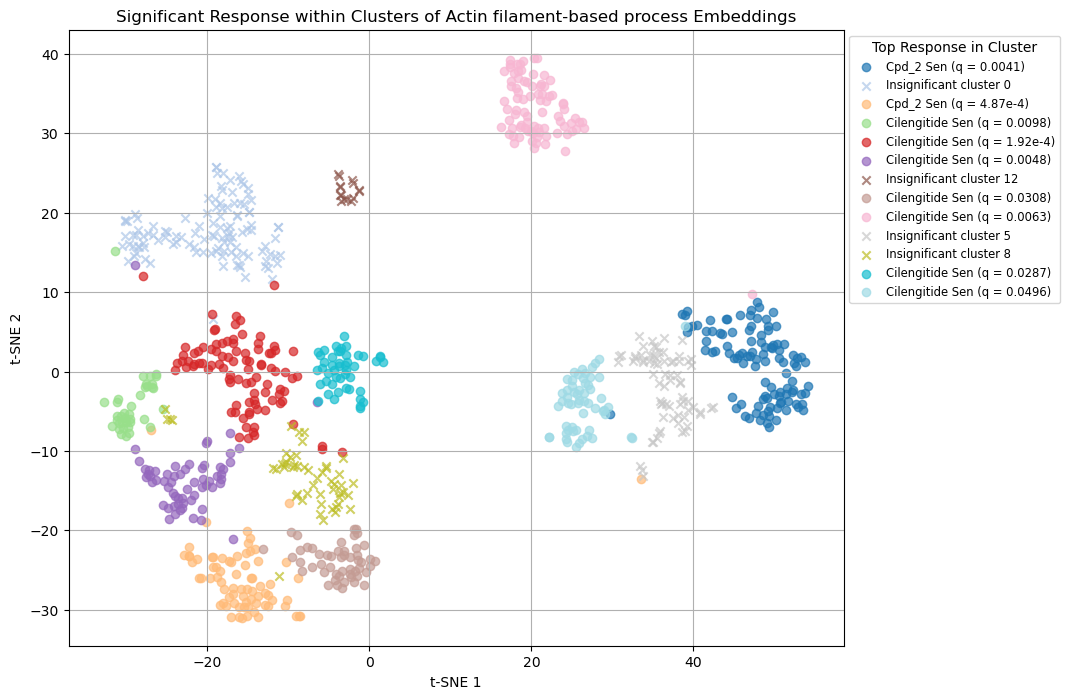

In [9]:
visualize_embedding_response_1(results, clustered_embeddings, "Actin filament-based process")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


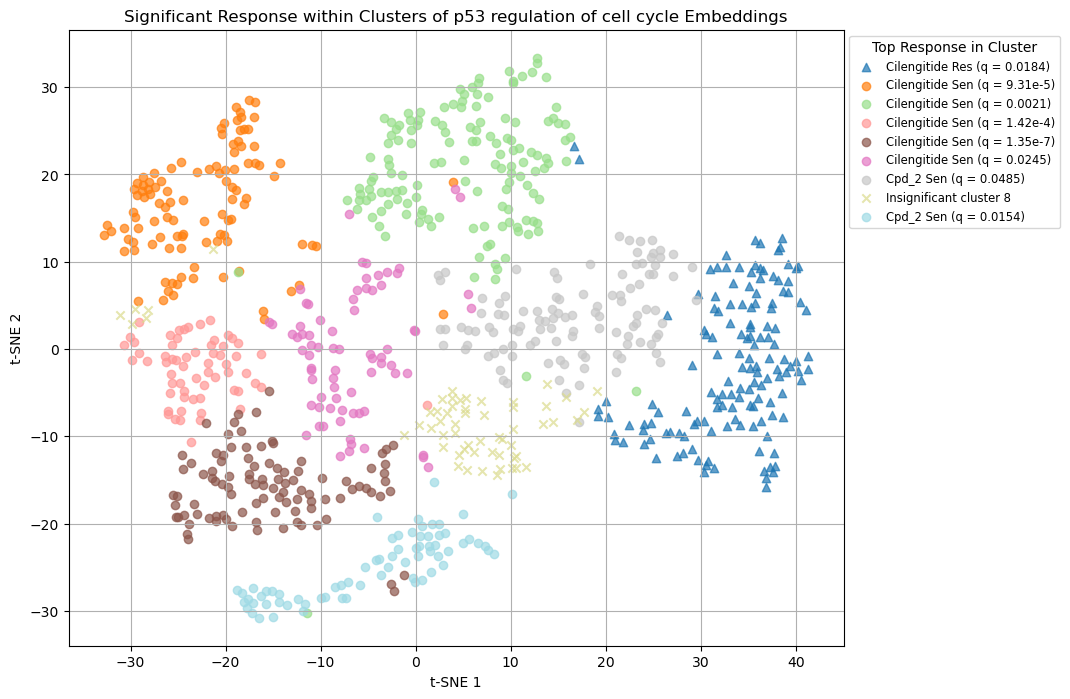

In [10]:
visualize_embedding_response_1(results, clustered_embeddings, "p53 regulation of cell cycle")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


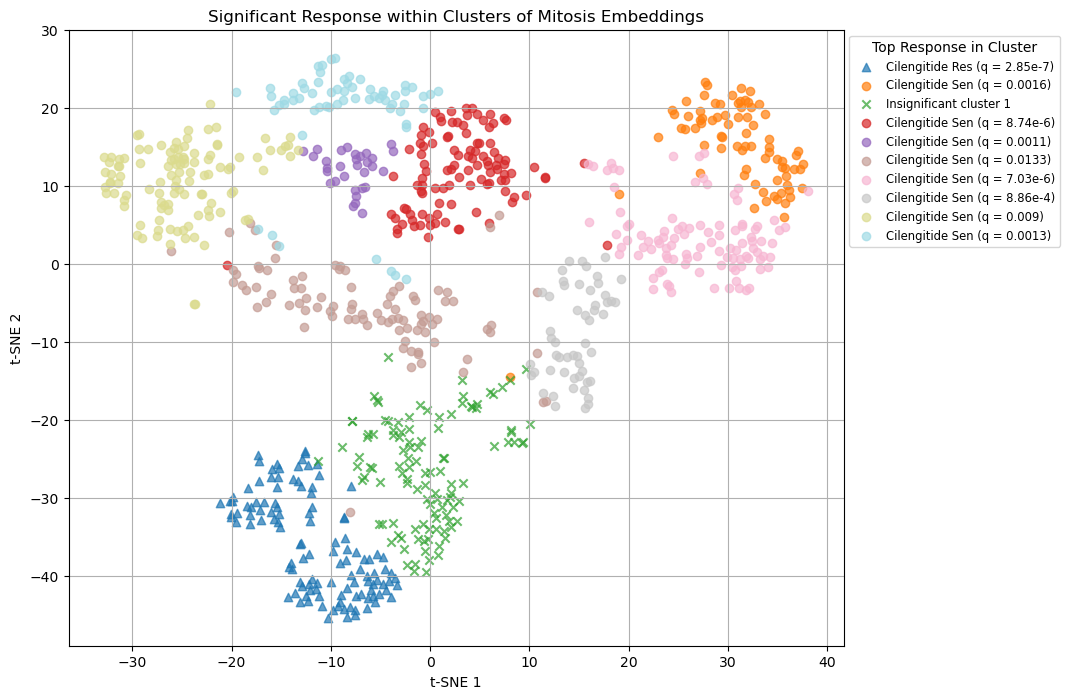

In [11]:
visualize_embedding_response_1(results, clustered_embeddings, "Mitosis")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


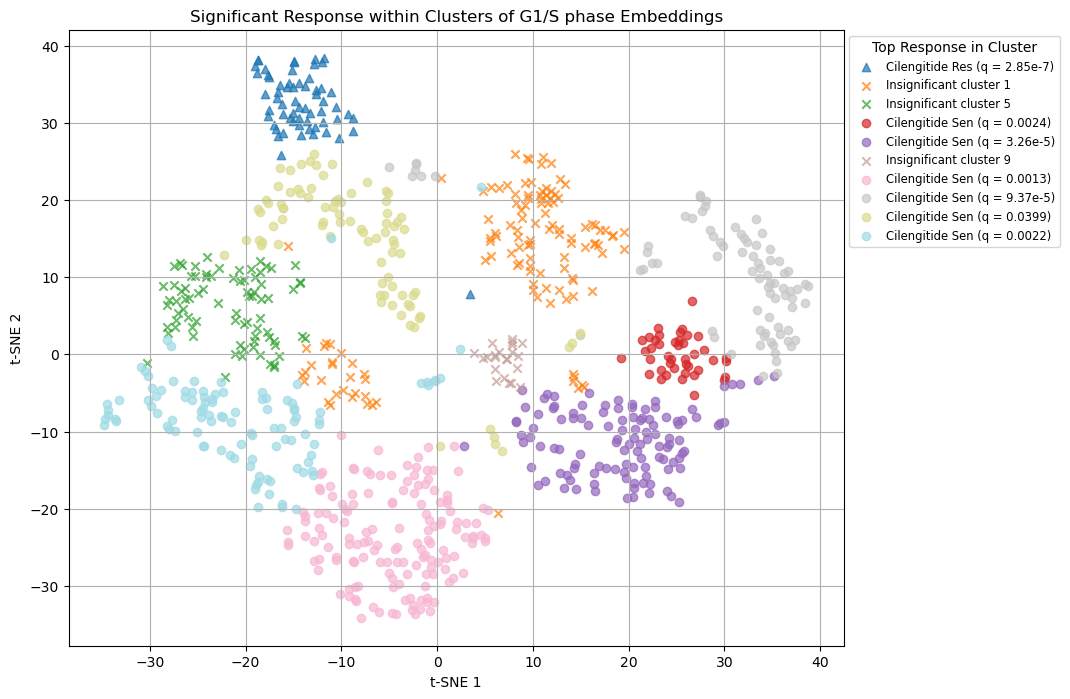

In [12]:
visualize_embedding_response_1(results, clustered_embeddings, "G1/S phase")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


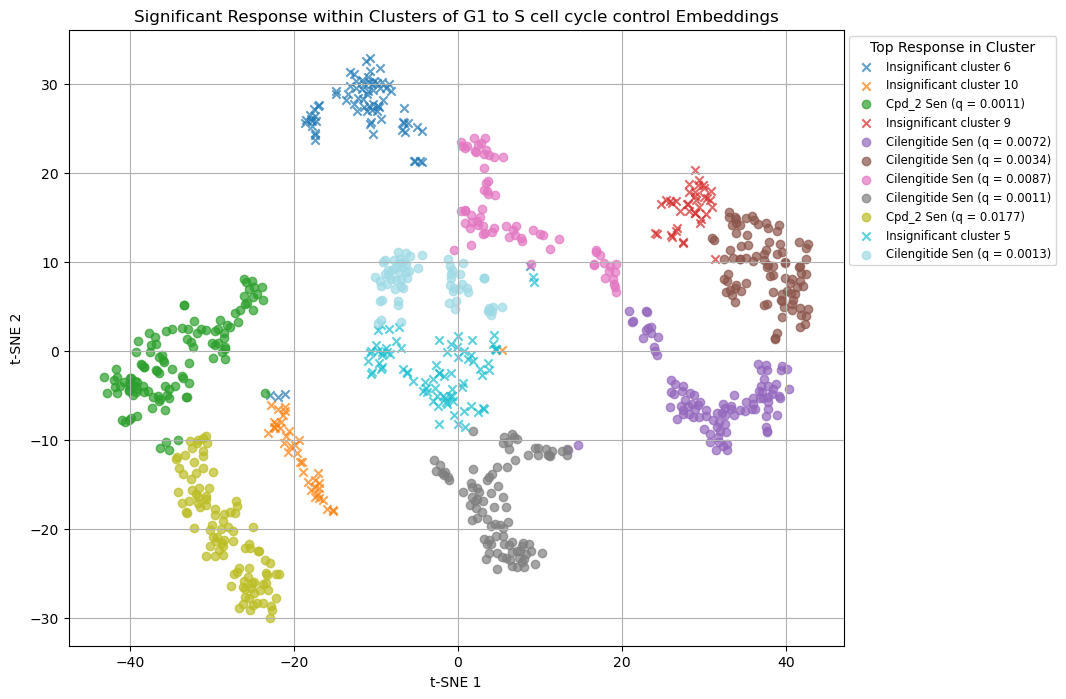

In [13]:
visualize_embedding_response_1(results, clustered_embeddings, "G1 to S cell cycle control")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


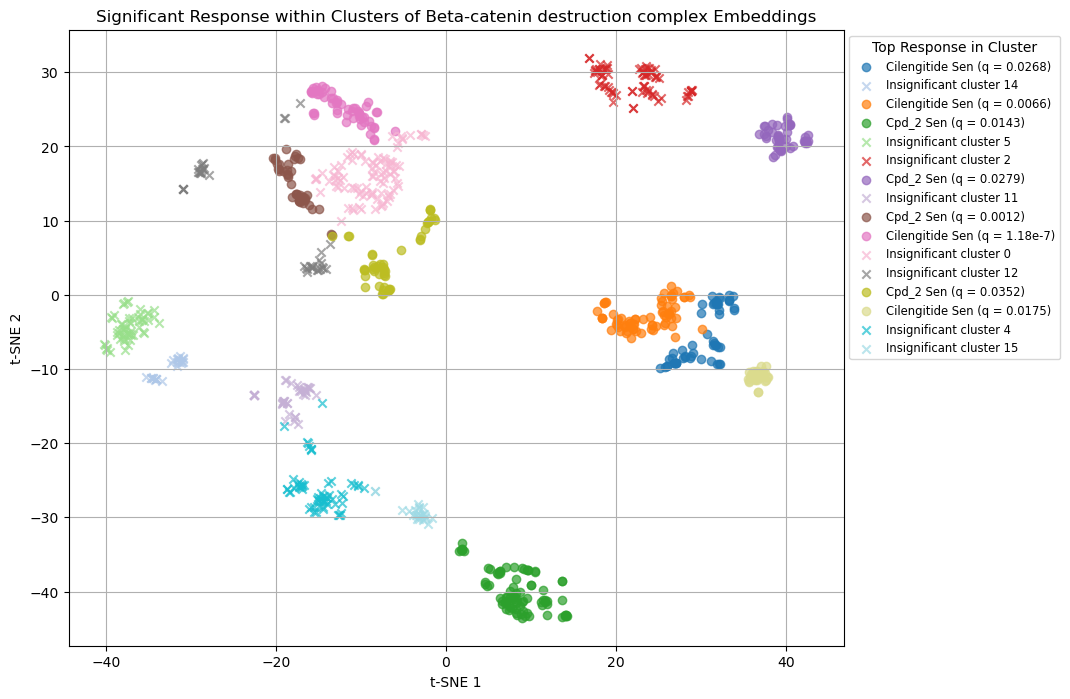

In [52]:
visualize_embedding_response_1(results, clustered_embeddings, "Beta-catenin destruction complex")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


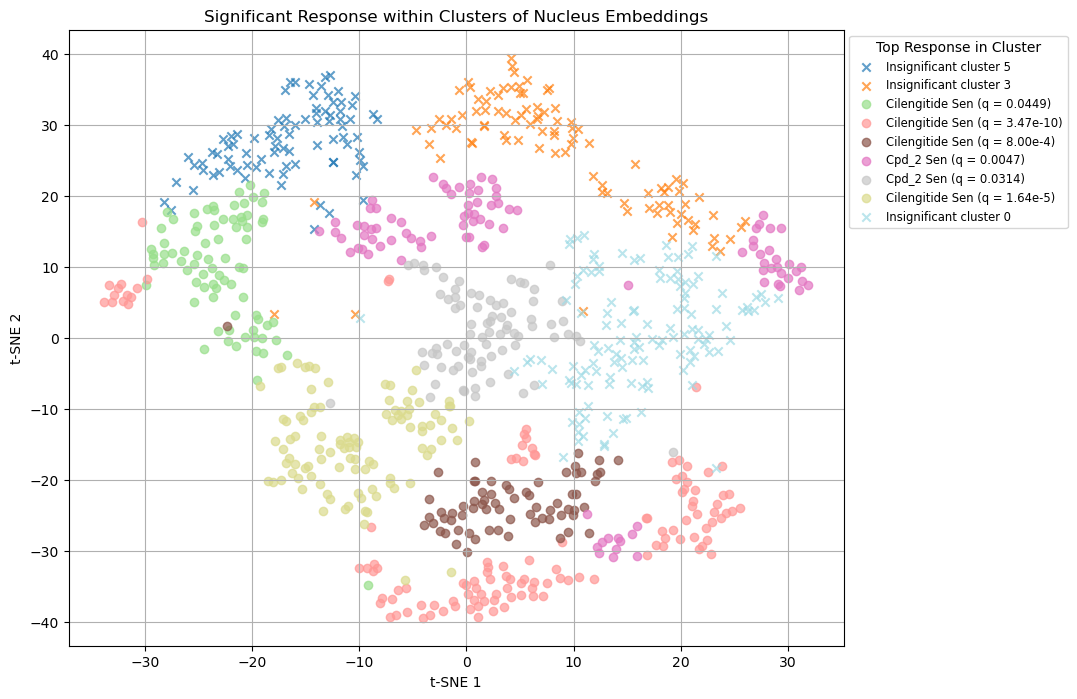

In [14]:
visualize_embedding_response_1(results, clustered_embeddings, "Nucleus")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


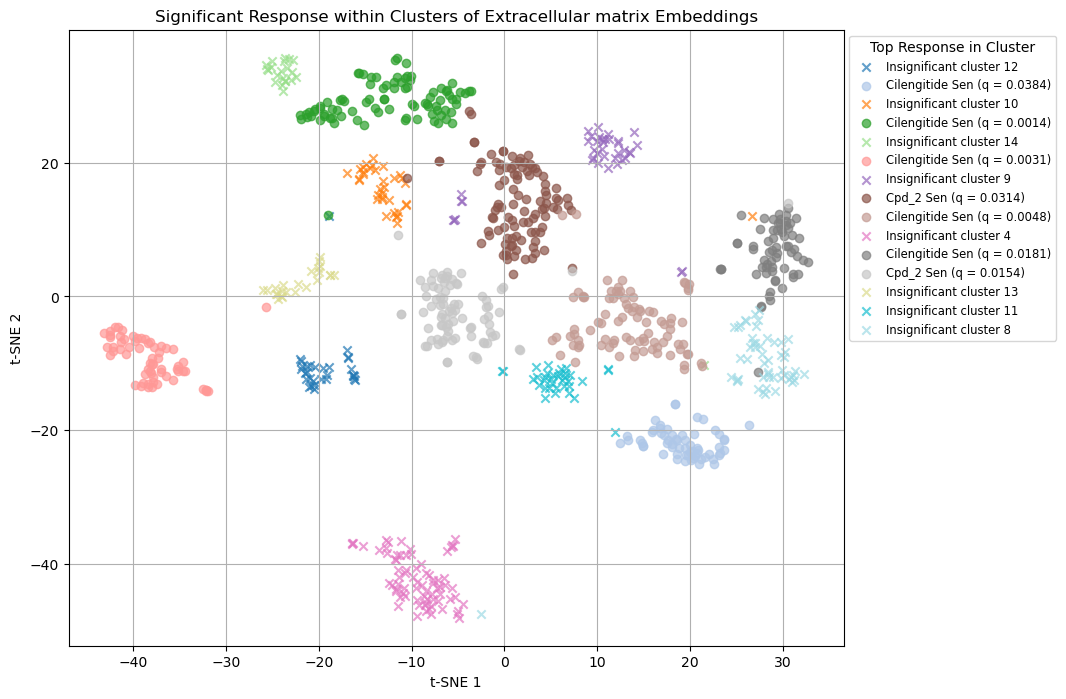

In [15]:
visualize_embedding_response_1(results, clustered_embeddings, "Extracellular matrix")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


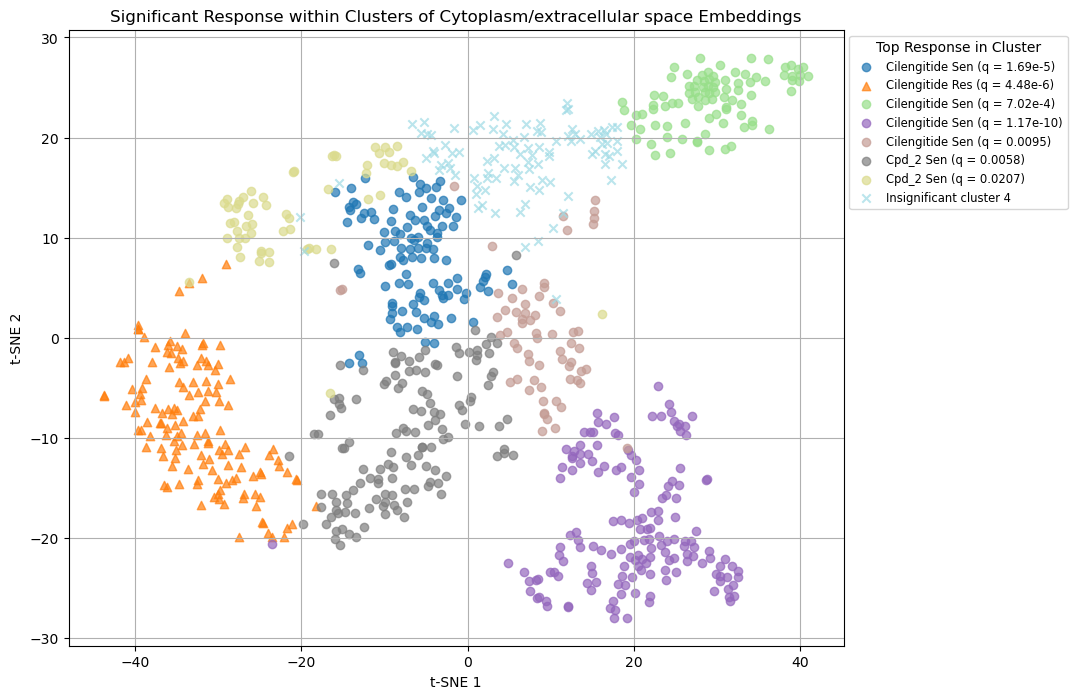

In [16]:
visualize_embedding_response_1(results, clustered_embeddings, "Cytoplasm/extracellular space")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


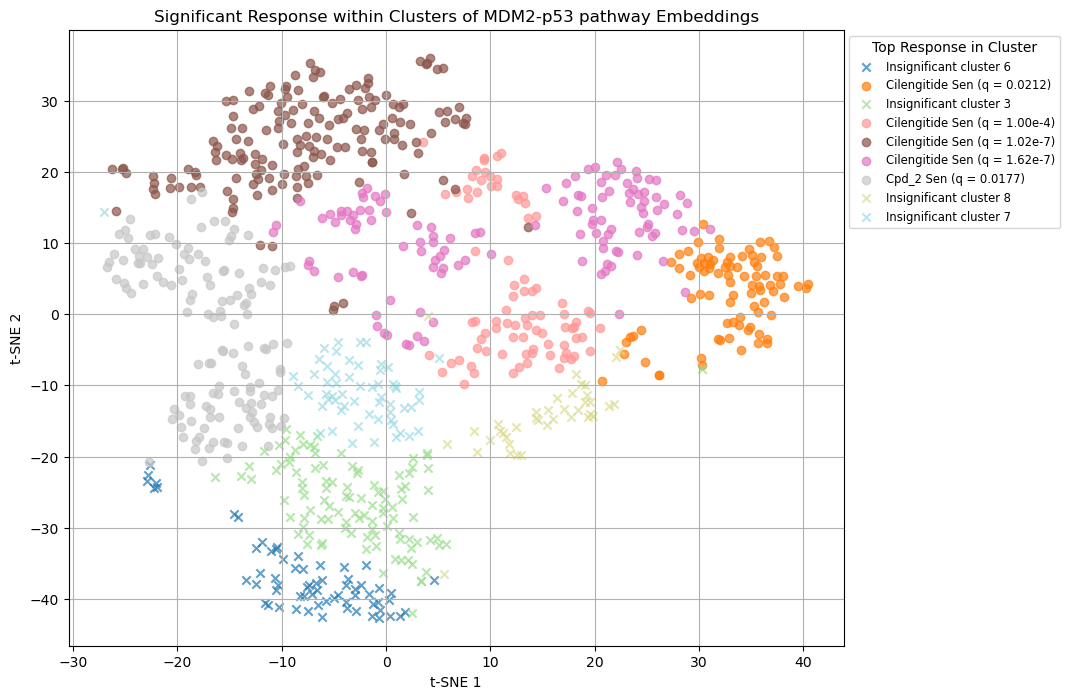

In [13]:
visualize_embedding_response_1(results, clustered_embeddings, "MDM2-p53 pathway")

## Visualize System Embedding Clusters Colored by Profile

### Code version 1

In [15]:
import numpy as np
import pandas as pd
from decimal import Decimal
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

def visualize_embedding_profile(results, cluster_info, system):
    # --- build up the big embeddings DataFrame as before ---
    name_to_nest = dict((v,k) for k,v in nest_to_name.items())
    nest_to_index = dict((v,k) for k,v in index_to_nest.items())
    system_index = nest_to_index[name_to_nest[system]]
    system_clusters = cluster_info[system]["Clusters"]

    system_embeddings = None
    for drug, res in results.items():
        cells = res["celllines"]
        emb = res["system_embeddings"][:, system_index, :]
        df = pd.DataFrame(emb, index=cells)
        if system_embeddings is None:
            system_embeddings = df
        else:
            system_embeddings = (pd.concat([system_embeddings, df], axis=0)
                                 .loc[lambda d: ~d.index.duplicated(keep='first')]
                                )

    # --- precompute cluster → point-indices mapping ---
    cluster_cells_indices = {}
    for clust_id, clust in system_clusters.items():
        inds = [system_embeddings.index.get_loc(c) for c in clust["Cells"]]
        cluster_cells_indices[clust_id] = inds

    # --- for each alteration type, build per-cluster legend labels ---
    alteration_types = ['mut', 'del', 'amp']
    legend_labels = {atype: {} for atype in alteration_types}
    for atype in alteration_types:
        for clust_id, clust in system_clusters.items():
            profiles = clust["Profiles"]
            # sort genes by their FDR for this alteration type
            sorted_genes = sorted(profiles.items(), key=lambda x: x[1][atype])
            # take up to top-5 with FDR < 0.05
            top = [(g, profiles[g][atype]) for g,_ in sorted_genes[:5] if profiles[g][atype] < 0.05]
            if top:
                genes, fdrs = zip(*top)
                fdr_strs = [
                    "{:.2e}".format(f) if f < 0.001 else str(round(f,4))
                    for f in fdrs
                ]
                lbl = f"{', '.join(genes)}"
            else:
                lbl = f"Insignificant"
            legend_labels[atype][clust_id] = lbl

    # --- run t-SNE ---
    matrix = system_embeddings.values
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    coords = tsne.fit_transform(matrix)

    # --- setup colors & figure ---
    n = len(cluster_cells_indices)
    cmap = cm.get_cmap("tab20", n)
    colors = [cmap(i) for i in range(n)]

    fig, ax = plt.subplots(figsize=(11, 8))

    # plot each cluster exactly once
    for i, (clust_id, inds) in enumerate(cluster_cells_indices.items()):
        ax.scatter(
            coords[inds, 0],
            coords[inds, 1],
            marker='p',
            color=colors[i],
            alpha=0.7
        )

    # create one proxy artist per cluster for all legends
    proxies = [
        Line2D([0], [0], marker='p', color='w', markerfacecolor=colors[i], markersize=10)
        for i in range(n)
    ]

    # positions for the three legends (tweak y if you like)
    legend_pos = {
        'mut': (1.01, 1.00),
        'del': (1.01, 0.71),
        'amp': (1.01, 0.42)
    }
    titles = {
        'mut': "Significant Mutations",
        'del': "Significant Deletions",
        'amp': "Significant Amplifications"
    }

    # build labels per alteration type
    labels_mut = [legend_labels['mut'][cid] for cid in cluster_cells_indices]
    labels_del = [legend_labels['del'][cid] for cid in cluster_cells_indices]
    labels_amp = [legend_labels['amp'][cid] for cid in cluster_cells_indices]

    # first legend: mutations
    leg_mut = ax.legend(
        proxies,
        labels_mut,
        title=titles['mut'],
        bbox_to_anchor=legend_pos['mut'],
        loc='upper left',
        #fontsize='small'
    )
    ax.add_artist(leg_mut)

    # second legend: deletions
    leg_del = ax.legend(
        proxies,
        labels_del,
        title=titles['del'],
        bbox_to_anchor=legend_pos['del'],
        loc='upper left',
        #fontsize='small'
    )
    ax.add_artist(leg_del)

    # third legend: amplifications (this one can be the "active" legend)
    ax.legend(
        proxies,
        labels_amp,
        title=titles['amp'],
        bbox_to_anchor=legend_pos['amp'],
        loc='upper left',
        #fontsize='small'
    )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(f"Significantly Altered Genes within Clusters of {system} Embeddings", fontsize=12)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

### Code Version 2

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE

def visualize_embedding_full(results, cluster_info, system):
    # Map system name to index
    name_to_nest  = {v:k for k,v in nest_to_name.items()}
    nest_to_index = {v:k for k,v in index_to_nest.items()}
    sys_idx       = nest_to_index[name_to_nest[system]]
    clusters      = cluster_info[system]["Clusters"]

    # Build embeddings DataFrame
    system_embeddings = None
    for drug, res in results.items():
        df = pd.DataFrame(res["system_embeddings"][:, sys_idx, :],
                          index=res["celllines"])
        if system_embeddings is None:
            system_embeddings = df
        else:
            merged = pd.concat([system_embeddings, df], axis=0)
            system_embeddings = merged.loc[~merged.index.duplicated(keep='first')]

    # Cluster → indices mapping
    cluster_order   = list(clusters.keys())
    cluster_indices = {
        cid: [system_embeddings.index.get_loc(c)
              for c in clusters[cid]["Cells"]
              if c in system_embeddings.index]
        for cid in cluster_order
    }

    # Compute majority response counts & markers
    total_drugs      = None
    resp_labels      = {}
    resp_markers     = {}
    resp_significant = {}
    for cid in cluster_order:
        resp = clusters[cid]["Response"]
        total_drugs = len(resp) if total_drugs is None else total_drugs
        res_count = sum(1 for d in resp if resp[d].get("Res FDR",1) < 0.05)
        sen_count = sum(1 for d in resp if resp[d].get("Sen FDR",1) < 0.05)

        if res_count > sen_count:
            label, marker = f"Resistant {res_count}/{total_drugs} drugs", "^"
        elif sen_count > res_count:
            label, marker = f"Sensitive {sen_count}/{total_drugs} drugs", "o"
        else:
            label, marker = "Insignificant Response", "x"

        resp_labels[cid]      = label
        resp_markers[cid]     = marker
        resp_significant[cid] = (res_count + sen_count) > 0

    # Alteration labels (only for clusters with significant response)
    alteration_types = ['mut','del','amp']
    alter_labels = {atype: {} for atype in alteration_types}
    for atype in alteration_types:
        for cid in cluster_order:
            if not resp_significant[cid]:
                alter_labels[atype][cid] = "Insignificant"
            else:
                profiles = clusters[cid]["Profiles"]
                top5 = [g for g,(stats) in sorted(
                    profiles.items(), key=lambda x: x[1][atype]
                ) if stats[atype] < 0.05][:11]
                alter_labels[atype][cid] = ", ".join(top5) if top5 else "Insignificant"

    # Run t-SNE
    coords = TSNE(n_components=2, perplexity=30, random_state=42)\
             .fit_transform(system_embeddings.values)

    # Set up colors & proxy artists (one per cluster)
    n = len(cluster_order)
    cmap = cm.get_cmap("tab20", n)
    colors = [cmap(i) for i in range(n)]
    proxies = [
        Line2D([0],[0],
               marker=resp_markers[cid],
               color=colors[i],
               linestyle='None',
               markersize=6)
        for i,cid in enumerate(cluster_order)
    ]

    # Shared legend kwargs to left‐align all markers
    legend_kwargs = dict(
        loc='upper left',
        fontsize='small',
        handlelength=1,
        handletextpad=0.5,
        borderaxespad=0.0,
        borderpad=0.4
    )

    # Plot points
    fig, ax = plt.subplots(figsize=(13,8))
    for i,cid in enumerate(cluster_order):
        ax.scatter(
            coords[cluster_indices[cid],0],
            coords[cluster_indices[cid],1],
            color=colors[i],
            marker=resp_markers[cid],
            alpha=0.7
        )

    # 1) Response legend
    labels_resp = [resp_labels[cid] for cid in cluster_order]
    resp_leg = ax.legend(
        proxies, labels_resp,
        title="Significant Response Outcomes",
        bbox_to_anchor=(1.01,1.00),
        **legend_kwargs
    )
    ax.add_artist(resp_leg)

    # 2) Mutations legend
    labels_mut = [alter_labels['mut'][cid] for cid in cluster_order]
    mut_leg = ax.legend(
        proxies, labels_mut,
        title="Significant Mutations",
        bbox_to_anchor=(1.01,0.75),
        **legend_kwargs
    )
    ax.add_artist(mut_leg)

    # 3) Deletions legend
    labels_del = [alter_labels['del'][cid] for cid in cluster_order]
    del_leg = ax.legend(
        proxies, labels_del,
        title="Significant Deletions",
        bbox_to_anchor=(1.01,0.50),
        **legend_kwargs
    )
    ax.add_artist(del_leg)

    # 4) Amplifications legend
    labels_amp = [alter_labels['amp'][cid] for cid in cluster_order]
    ax.legend(
        proxies, labels_amp,
        title="Significant Amplifications",
        bbox_to_anchor=(1.01,0.25),
        **legend_kwargs
    )

    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(f"Responses & Alterations in Cells Clustered by the State of the {system} System", fontsize=12)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


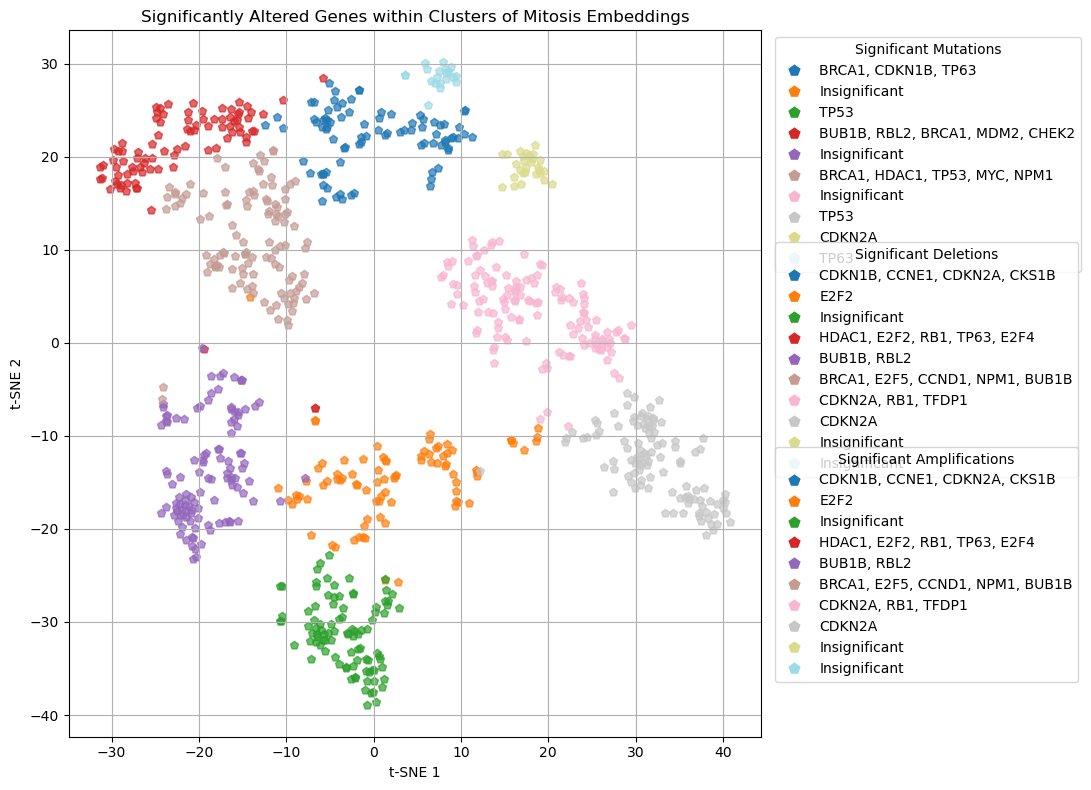

In [23]:
visualize_embedding_profile(results, clustered_embeddings, "Mitosis")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


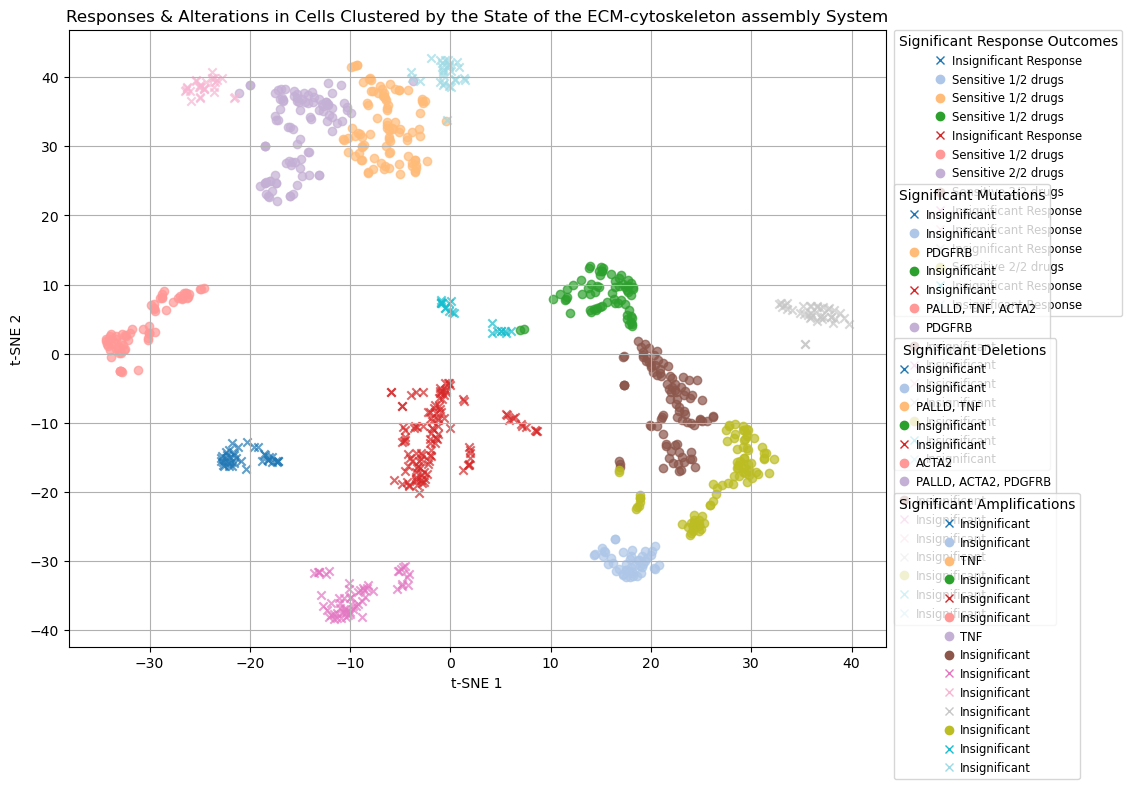

In [17]:
visualize_embedding_full(results, clustered_embeddings, "ECM-cytoskeleton assembly")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


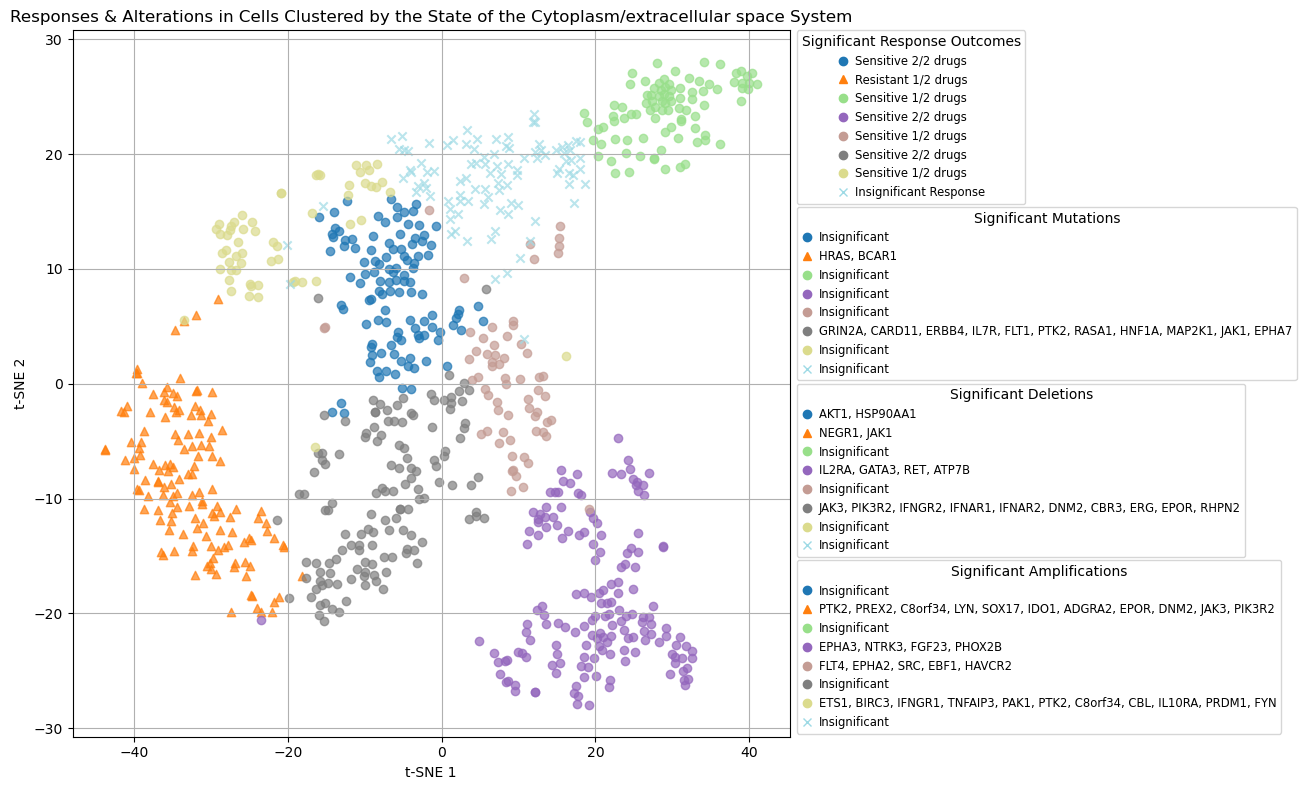

In [43]:
visualize_embedding_full(results, clustered_embeddings, "Cytoplasm/extracellular space")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


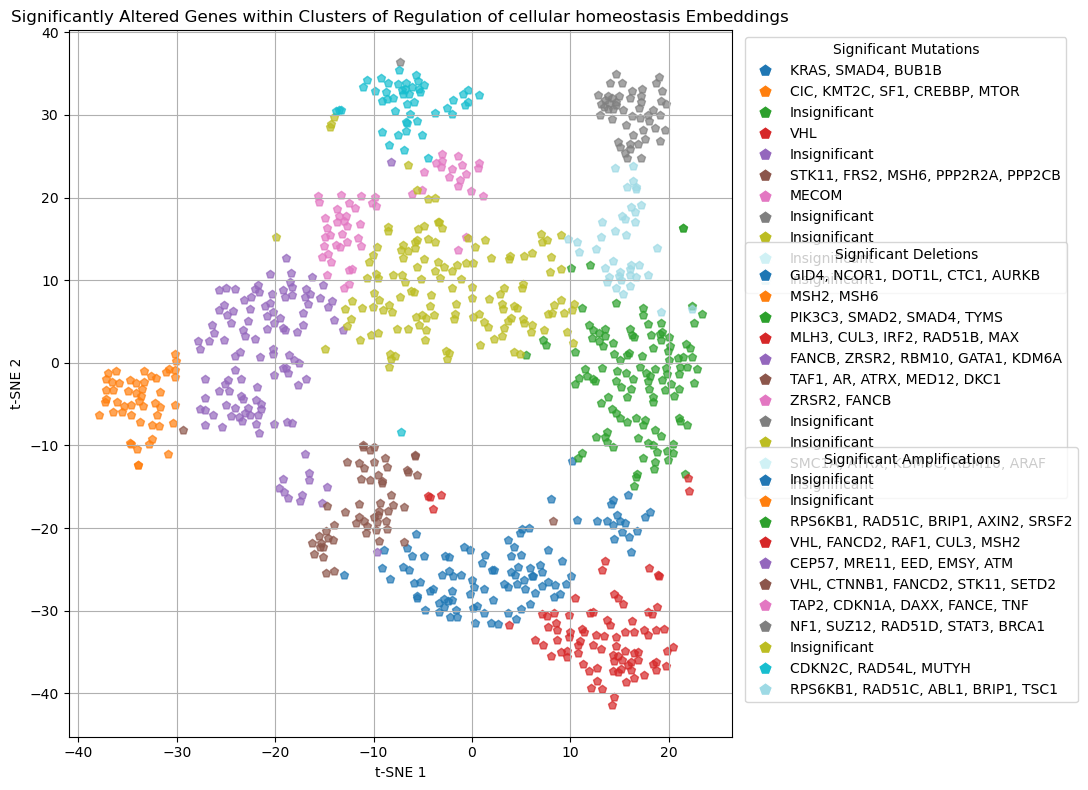

In [20]:
visualize_embedding_profile(results, clustered_embeddings, "Regulation of cellular homeostasis")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


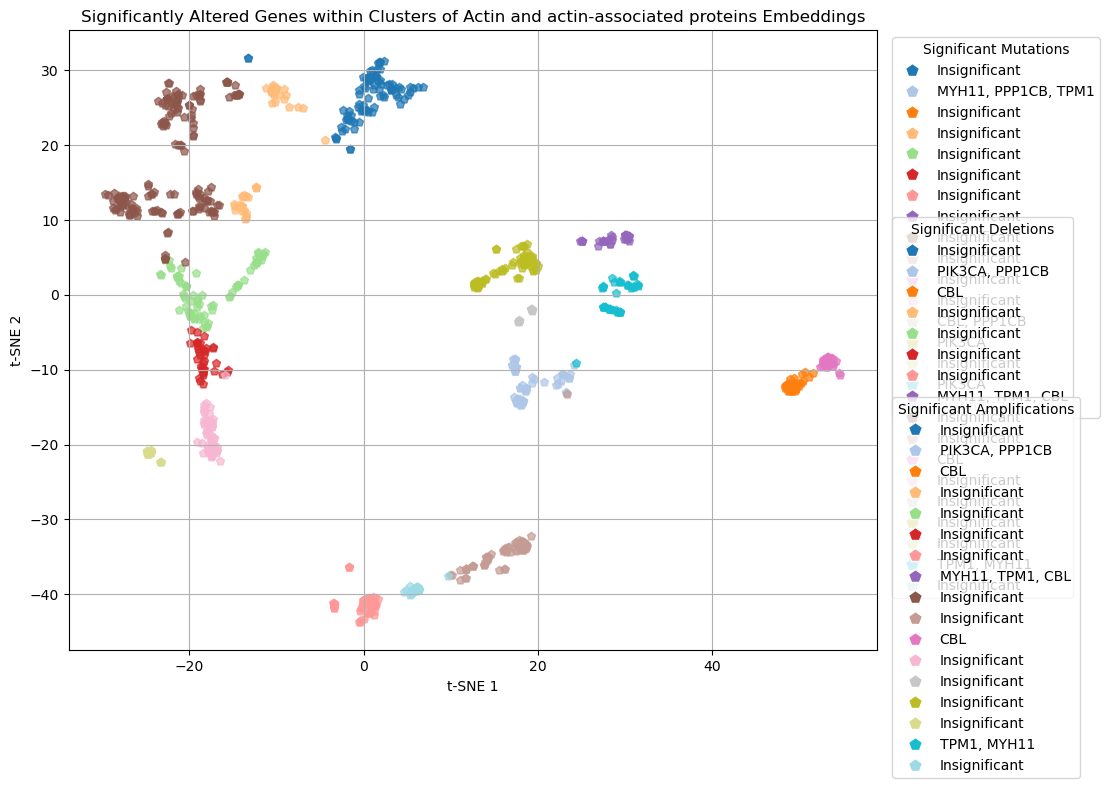

In [27]:
visualize_embedding_profile(results, clustered_embeddings, "Actin and actin-associated proteins")

/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/cellar/users/zwallace/miniconda3/envs/g2pt_env/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


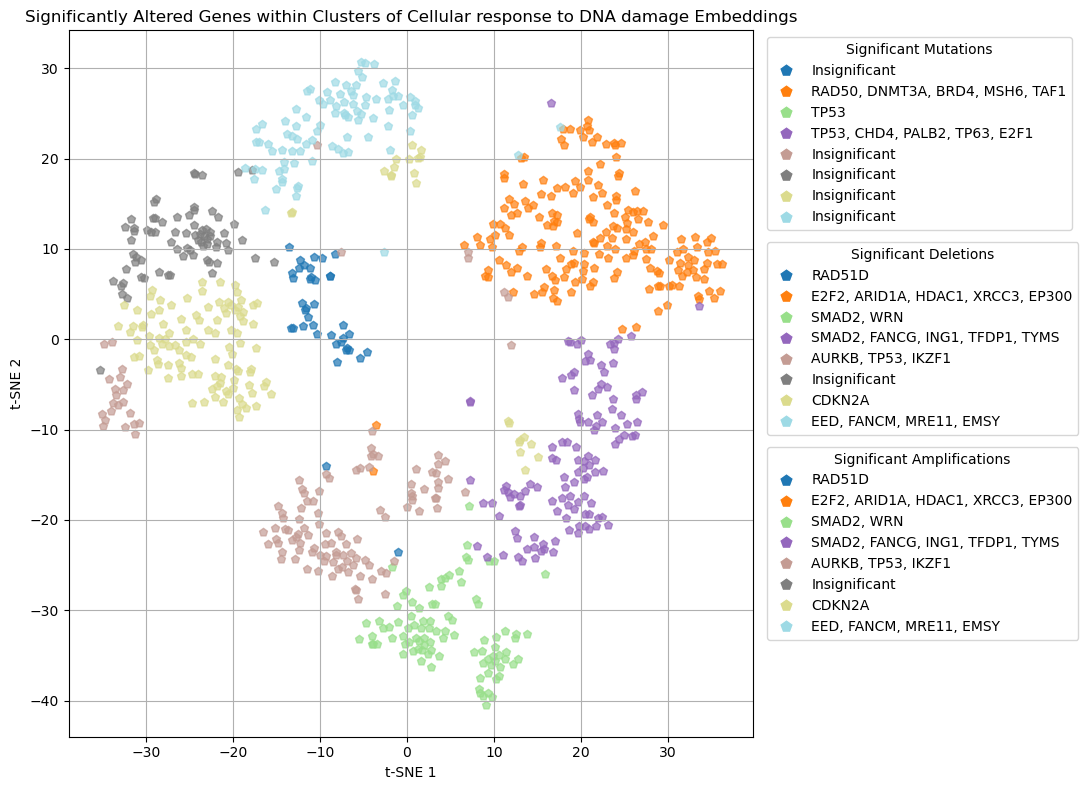

In [28]:
visualize_embedding_profile(results, clustered_embeddings, "Cellular response to DNA damage")

## Create a DataFrame that can be Used to Analyze the Top Results

In [7]:
import math

def round_to_sf(x):
    
    if x == 0:
        return 0.0
    else:
        return round(x, -int(math.floor(math.log10(abs(x)))) + 3)

clusters_df = []
total_clusters = 0
non_sig_clusters = 0
cluster_id = 0
cluster_to_cells = {}
name_to_nest = dict((v,k) for k,v in nest_to_name.items())
for system in clustered_embeddings.keys():
    nest_id = name_to_nest[system]
    system_clusters = clustered_embeddings[system]
    for cluster in system_clusters["Clusters"].keys():
        total_clusters += 1
        cells = list(system_clusters["Clusters"][cluster]["Cells"])
        cluster_size = len(cells)
        profiles = system_clusters["Clusters"][cluster]["Profiles"]
        response = system_clusters["Clusters"][cluster]["Response"]
        #significant_any = [gene+": "+str(round_to_sf(profiles[gene]["any"])) for gene in profiles.keys() if profiles[gene]["any"] < 0.05]
        significant_mut = [gene+": "+str(round_to_sf(profiles[gene]["mut"])) for gene in profiles.keys() if profiles[gene]["mut"] < 0.05]
        significant_amp = [gene+": "+str(round_to_sf(profiles[gene]["amp"])) for gene in profiles.keys() if profiles[gene]["amp"] < 0.05]
        significant_del = [gene+": "+str(round_to_sf(profiles[gene]["del"])) for gene in profiles.keys() if profiles[gene]["del"] < 0.05]
        system_size = len(profiles.keys())
        
        if significant_mut != []:
            significant_mut = "; ".join(significant_mut)
        else:
             significant_mut = "WT"
        if significant_amp != []:
            significant_amp = "; ".join(significant_amp)
        else:
             significant_amp = "WT"
        if significant_del != []:
            significant_del = "; ".join(significant_del)
        else:
             significant_del = "WT"

        significant_cluster = False
        for drug in response.keys():
            importance = importance_pvalues[drug][system]
            if importance > 1:
                importance = 1
            res_fdr = response[drug]["Res FDR"]
            sen_fdr = response[drug]["Sen FDR"]
            acc_fdr = response[drug]["Acc FDR"]
            if res_fdr < 0.05:
                cluster_response = "Resistant"
                response_fdr = round_to_sf(res_fdr)
            elif sen_fdr < 0.05:
                cluster_response = "Sensitive"
                response_fdr = round_to_sf(sen_fdr)
            else:
                continue
            if acc_fdr < 0.05:
                significant_cluster = True
                or_fdr = round_to_sf(acc_fdr)
                data = pd.DataFrame({"Cluster ID": [cluster_id], "Drug": [drug], "NeST System": [system], "NeST ID": [nest_id], 
                                     "System Importance Pvalue": [importance], "Num. of Genes": [system_size], 
                                     "Num. of Cells": [cluster_size], "Response": [cluster_response], "Response FDR": [response_fdr], 
                                     "Odds Ratio FDR": [or_fdr], "Mutated (Gene: FDR)": [significant_mut], 
                                     "Amplified (Gene: FDR)": [significant_amp], "Deleted (Gene: FDR)": [significant_del]})
                clusters_df.append(data)

        if significant_cluster == False:
            non_sig_clusters += 1

        cluster_to_cells[cluster_id] = ", ".join(cells)
        cluster_id += 1
                

clusters_df = pd.concat(clusters_df, ignore_index = True)
#clusters_df = clusters_df.sort_values(by = ["Response FDR", "Odds Ratio FDR"], ascending = [True, True])

sensitive_clusters = clusters_df[(clusters_df["Response"] == "Sensitive")]
resistant_clusters = clusters_df[(clusters_df["Response"] == "Resistant")]

cluster_to_cells = pd.DataFrame([[key, value] for key, value in cluster_to_cells.items()], columns=['Cluster ID', 'Cell-Lines'])

pd.options.display.float_format = '{:g}'.format

In [8]:
clusters_df

,Cluster ID,Drug,NeST System,NeST ID,System Importance Pvalue,Num. of Genes,Num. of Cells,Response,Response FDR,Odds Ratio FDR,Mutated (Gene: FDR),Amplified (Gene: FDR),Deleted (Gene: FDR)
0,2,Cilengitide,Cell,NEST,1,718,145,Sensitive,6.128e-11,4.181e-15,WT,ABCB1: 0.02094; ABL2: 0.03675; APC: 0.00288; A...,WT
1,2,Cpd_2,Cell,NEST,0.0174935,718,145,Sensitive,0.006303,8.515e-22,WT,ABCB1: 0.02094; ABL2: 0.03675; APC: 0.00288; A...,WT
2,3,Cilengitide,Cell,NEST,1,718,70,Sensitive,1.49e-07,2.873e-06,WT,WT,ACTA2: 0.01584; AJUBA: 0.003501; AKT1: 0.00259...
3,4,Cilengitide,Cell,NEST,1,718,104,Sensitive,0.0002025,1.903e-14,ARID1A: 0.02378; ARID1B: 0.02905; ATRX: 0.0057...,WT,GSTP1: 0.01715; MEN1: 0.02102; RAD51C: 0.04105...
4,4,Cpd_2,Cell,NEST,0.0174935,718,104,Sensitive,6.488e-06,5.911e-10,ARID1A: 0.02378; ARID1B: 0.02905; ATRX: 0.0057...,WT,GSTP1: 0.01715; MEN1: 0.02102; RAD51C: 0.04105...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,1400,Cilengitide,Histone methyltransferase complex,NEST:98,1,11,73,Sensitive,0.0004493,1.485e-07,CTNNB1: 0.001715,KMT2A: 0.007719; TNF: 3.3e-36,WT
1191,1401,Cilengitide,Histone methyltransferase complex,NEST:98,1,11,104,Sensitive,0.0003231,6.995e-12,WT,KMT2A: 0.0012,WT
1192,1401,Cpd_2,Histone methyltransferase complex,NEST:98,1,11,104,Sensitive,0.004731,2.809e-12,WT,KMT2A: 0.0012,WT
1193,1402,Cilengitide,Histone methyltransferase complex,NEST:98,1,11,145,Sensitive,3.418e-05,3.402e-23,WT,KMT2C: 2.234e-57; MAGI2: 2.923e-76,WT


### Save cluster results

In [9]:
clusters_df.to_csv("integrin_cluster_annotations.csv", index = False)
cluster_to_cells.to_csv("integrin_cluster_to_cells.txt", index = False, sep = '\t')

## Finding Opposite Alterations

Find gene of NeST systems that are oppositely altered between clusters opposite in response

In [10]:
import pandas as pd

rows = []

for system, system_clusters in clustered_embeddings.items():
    # initialize
    resistant_alts = {"mut": set(), "amp": set(), "del": set()}
    sensitive_alts  = {"mut": set(), "amp": set(), "del": set()}
    resistant_drugs = []
    sensitive_drugs = []

    # collect per‐cluster
    for cluster_data in system_clusters["Clusters"].values():
        response = cluster_data["Response"]
        profiles = cluster_data["Profiles"]

        for drug, vals in response.items():
            res_fdr = vals["Res FDR"]
            sen_fdr = vals["Sen FDR"]
            acc_fdr = vals["Acc FDR"]

            if acc_fdr < 0.05:
                # mark drug
                if res_fdr < 0.05:
                    for g, p in profiles.items():
                        if p["mut"] < 0.05: 
                            resistant_alts["mut"].add(g)
                            resistant_drugs.append(drug)
                        if p["amp"] < 0.05: 
                            resistant_alts["amp"].add(g)
                            resistant_drugs.append(drug)
                        if p["del"] < 0.05: 
                            resistant_alts["del"].add(g)
                            resistant_drugs.append(drug)

                elif sen_fdr < 0.05:
                    for g, p in profiles.items():
                        if p["mut"] < 0.05: 
                            sensitive_alts["mut"].add(g)
                            sensitive_drugs.append(drug)
                        if p["amp"] < 0.05: 
                            sensitive_alts["amp"].add(g)
                            sensitive_drugs.append(drug)
                        if p["del"] < 0.05: 
                            sensitive_alts["del"].add(g)
                            sensitive_drugs.append(drug)

    # de‐dup drug lists
    resistant_drugs = list(set(resistant_drugs)) or ["X"]
    sensitive_drugs = list(set(sensitive_drugs)) or ["X"]

    # 1) drop genes that are both amp & del in *either* set
    invalid_R = resistant_alts["amp"] & resistant_alts["del"]
    invalid_S = sensitive_alts["amp"] & sensitive_alts["del"]
    invalid   = invalid_R | invalid_S

    # all candidates
    all_genes = set().union(*resistant_alts.values(), *sensitive_alts.values())
    valid_genes = all_genes - invalid

    opp_res = set()   # genes opposite in resistant ↔ sensitive
    opp_sen = set()

    for g in valid_genes:
        Rm = g in resistant_alts["mut"]
        Ra = g in resistant_alts["amp"]
        Rd = g in resistant_alts["del"]
        Sm = g in sensitive_alts["mut"]
        Sa = g in sensitive_alts["amp"]
        Sd = g in sensitive_alts["del"]

        # NEW: drop any gene that shares *any* alteration type across R vs S
        if (Rm and Sm) or (Ra and Sa) or (Rd and Sd):
            continue

        # now apply your 5 “opposite” rules for Resistant → Sensitive
        if Rm and ((Sa ^ Sd) and not Sm):
            opp_res.add(g)
        if Ra and not (Rm or Rd) and (Sm or Sd):
            opp_res.add(g)
        if Rd and not (Rm or Ra) and (Sm or Sa):
            opp_res.add(g)
        if (Rm and Ra) and (Sd and not (Sm or Sa)):
            opp_res.add(g)
        if (Rm and Rd) and (Sa and not (Sm or Sd)):
            opp_res.add(g)

        # …and the symmetric 5 rules for Sensitive → Resistant
        if Sm and ((Ra ^ Rd) and not Rm):
            opp_sen.add(g)
        if Sa and not (Sm or Sd) and (Rm or Rd):
            opp_sen.add(g)
        if Sd and not (Sm or Sa) and (Rm or Ra):
            opp_sen.add(g)
        if (Sm and Sa) and (Rd and not (Rm or Ra)):
            opp_sen.add(g)
        if (Sm and Sd) and (Ra and not (Rm or Rd)):
            opp_sen.add(g)


    # helper to build each row
    def mkrow(what, drug_list, opp_set, alts):
        muts = [g for g in opp_set if g in alts["mut"]] or ["X"]
        amps = [g for g in opp_set if g in alts["amp"]] or ["X"]
        dels = [g for g in opp_set if g in alts["del"]] or ["X"]
        # only include if there's at least one “real” gene
        if opp_set:
            return {
                "System": system,
                "NeST ID": name_to_nest[system],
                "Num. of Genes": len(system_genes[system]),
                "Drugs": ", ".join(drug_list),
                "Response": what,
                "Mutated": ", ".join(muts),
                "Amplified": ", ".join(amps),
                "Deleted": ", ".join(dels)
            }
        else:
            return None

    r_row = mkrow("Resistant", resistant_drugs, opp_res, resistant_alts)
    s_row = mkrow("Sensitive", sensitive_drugs, opp_sen, sensitive_alts)

    for row in (r_row, s_row):
        if row:
            rows.append(row)

# final dataframe
df_opposite = pd.DataFrame(rows)
df_opposite

,System,NeST ID,Num. of Genes,Drugs,Response,Mutated,Amplified,Deleted
0,Signaling pathways,NEST:1,216,Cilengitide,Resistant,X,NOTCH1,"CTRC, RHOA, EGF, PDGFRA, FOXO3, EP300, SDHB"
1,Signaling pathways,NEST:1,216,"Cilengitide, Cpd_2",Sensitive,"RHOA, EGF, PDGFRA, NOTCH1, EP300","CTRC, FOXO3, SDHB",X
2,Cellular response to DNA damage,NEST:15,128,Cilengitide,Resistant,MLH1,DNMT3B,AR
3,Cellular response to DNA damage,NEST:15,128,"Cilengitide, Cpd_2",Sensitive,"AR, DNMT3B",X,MLH1
4,Cytoplasm/extracellular space,NEST:2,238,Cilengitide,Resistant,BCAR1,"PIK3R2, EPOR, DNM2, JAK3",JAK1
5,Cytoplasm/extracellular space,NEST:2,238,"Cilengitide, Cpd_2",Sensitive,"PIK3R2, JAK1",BCAR1,"PIK3R2, EPOR, DNM2, JAK3"
6,Beta-catenin,NEST:221,5,Cilengitide,Resistant,X,X,CTNNB1
7,Beta-catenin,NEST:221,5,"Cilengitide, Cpd_2",Sensitive,X,CTNNB1,X
8,Regulation of cellular homeostasis,NEST:3,323,Cilengitide,Resistant,"PRDM1, SMAD2, HDAC1, MIB1, TSC2, SMARCA1, HDAC...",X,MSH2
9,Regulation of cellular homeostasis,NEST:3,323,"Cilengitide, Cpd_2",Sensitive,X,"HDAC5, MAGI2, MSH2, RPTOR, CUX1, RARA, AXIN2, ...","PRDM1, SMAD2, HDAC1, MIB1, TSC2, SMARCA1, IRF2..."


In [11]:
df_opposite.to_csv("integrin_oppositely_altered.txt", index = False, sep = '\t')

## Find Genes with High Amps/Dels to Res/Sen

For each gene count the number of times it is found in a significantly resistant cluster and amplified, deleted, or mutated. Likewise, for each gene, count the number of times it is found in a significantly sensitive cluster and amplified, deleted, or mutated.